## Viscous Burgers equation
$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$
where $u$ is fluid velocity, $t$ is time and $x$ is space and $\nu$ is viscous coefficient

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
filename = 'Burgers.npz'

if os.path.exists(filename):
    print(f"Loading reference dataset from '{filename}'...")
    data = np.load(filename)
    t_ref = data['t'].flatten()      # Shape: (Nt,)
    x_ref = data['x'].flatten()      # Shape: (Nx,)
    u_ref = data['usol'].T           # Shape: (Nt, Nx) -> e.g., (100, 256)
else:
    print(f"'{filename}' not found. Generating synthetic reference grid")
    # Creating a dummy grid matching the exact dimensions of the classic benchmark
    t_ref = np.linspace(0.0, 0.99, 100)
    x_ref = np.linspace(-1.0, 1.0, 256)
    X_m, T_m = np.meshgrid(x_ref, t_ref)
    # A simple analytical wave approximation for structural visualization
    u_ref = -np.sin(np.pi * X_m) * np.exp(-T_m * 0.1)

print(f"Reference shapes -> t: {t_ref.shape}, x: {x_ref.shape}, u: {u_ref.shape}")

Loading reference dataset from 'Burgers.npz'...
Reference shapes -> t: (100,), x: (256,), u: (100, 256)


In [4]:
class BurgersPINN(nn.Module):
    def __init__(self, n_hidden=128, n_layers=5):
        super(BurgersPINN, self).__init__()

        layers = []
        # Input Layer (x, t)
        layers.append(nn.Linear(2, n_hidden))
        layers.append(nn.Tanh())

        # Deep Hidden Layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.Tanh())

        # Output Layer (u)
        layers.append(nn.Linear(n_hidden, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

# Initialize the model
model = BurgersPINN(n_hidden=128, n_layers=5)

In [5]:
def derivative(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

In [6]:
def physics_loss(model, x, t, nu=0.01):
    """Strong-form PDE Residual Loss"""
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    du_dt = derivative(u, t)
    du_dx = derivative(u, x)
    d2u_dx2 = derivative(du_dx, x)

    # Burgers Equation formulation
    residual = du_dt + u * du_dx - (nu / np.pi) * d2u_dx2
    return torch.mean(residual ** 2)

def boundary_loss(model, t_boundary):
    """Dirichlet Boundary Conditions: u(-1, t) = 0, u(1, t) = 0"""
    x_left = torch.full_like(t_boundary, -1.0)
    x_right = torch.full_like(t_boundary, 1.0)

    u_left = model(x_left, t_boundary)
    u_right = model(x_right, t_boundary)

    return torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

def initial_loss(model, x_initial, t_initial, u_initial):
    """Initial Condition Loss"""
    u_pred = model(x_initial, t_initial)
    return torch.mean((u_pred - u_initial) ** 2)

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Configuration Parameters
epochs = 10000
print_every = 500
nu_value = 0.01

N_interior = 2000
N_boundary = 200
N_initial = 200

x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 0.99

print("\nTraining Burgers PINN...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # Dynamic Sampling Phase: Points change every epoch to maximize domain search
    x_int = torch.rand(N_interior, 1) * (x_max - x_min) + x_min
    t_int = torch.rand(N_interior, 1) * t_max

    t_bd = torch.rand(N_boundary, 1) * t_max

    x_init = torch.rand(N_initial, 1) * (x_max - x_min) + x_min
    t_init = torch.zeros(N_initial, 1)
    u_init = -torch.sin(np.pi * x_init)

    # Calculate losses
    l_physics = physics_loss(model, x_int, t_int, nu=nu_value)
    l_boundary = boundary_loss(model, t_bd)
    l_ic = initial_loss(model, x_init, t_init, u_init)

    loss = l_physics + l_boundary + l_ic

    loss.backward()
    optimizer.step()

    if (epoch + 1) % print_every == 0:
        print(f"Epoch {epoch+1:4d} | Total Loss: {loss.item():.6f} | "
              f"PDE: {l_physics.item():.6f} | BC: {l_boundary.item():.6f} | IC: {l_ic.item():.6f}")


Training Burgers PINN...
Epoch  500 | Total Loss: 0.102509 | PDE: 0.045569 | BC: 0.002269 | IC: 0.054672
Epoch 1000 | Total Loss: 0.092313 | PDE: 0.040605 | BC: 0.002581 | IC: 0.049127
Epoch 1500 | Total Loss: 0.085117 | PDE: 0.036782 | BC: 0.001982 | IC: 0.046353
Epoch 2000 | Total Loss: 0.079780 | PDE: 0.026639 | BC: 0.000666 | IC: 0.052476
Epoch 2500 | Total Loss: 0.078856 | PDE: 0.039303 | BC: 0.001053 | IC: 0.038500
Epoch 3000 | Total Loss: 0.050633 | PDE: 0.022582 | BC: 0.000283 | IC: 0.027768
Epoch 3500 | Total Loss: 0.071399 | PDE: 0.043981 | BC: 0.002786 | IC: 0.024633
Epoch 4000 | Total Loss: 0.009827 | PDE: 0.004248 | BC: 0.000199 | IC: 0.005380
Epoch 4500 | Total Loss: 0.067061 | PDE: 0.030172 | BC: 0.000128 | IC: 0.036761
Epoch 5000 | Total Loss: 0.018533 | PDE: 0.008445 | BC: 0.000236 | IC: 0.009852
Epoch 5500 | Total Loss: 0.006536 | PDE: 0.002517 | BC: 0.000099 | IC: 0.003920
Epoch 6000 | Total Loss: 0.006092 | PDE: 0.002238 | BC: 0.000041 | IC: 0.003813
Epoch 6500 | T


Training Complete. R² Score: 99.90%


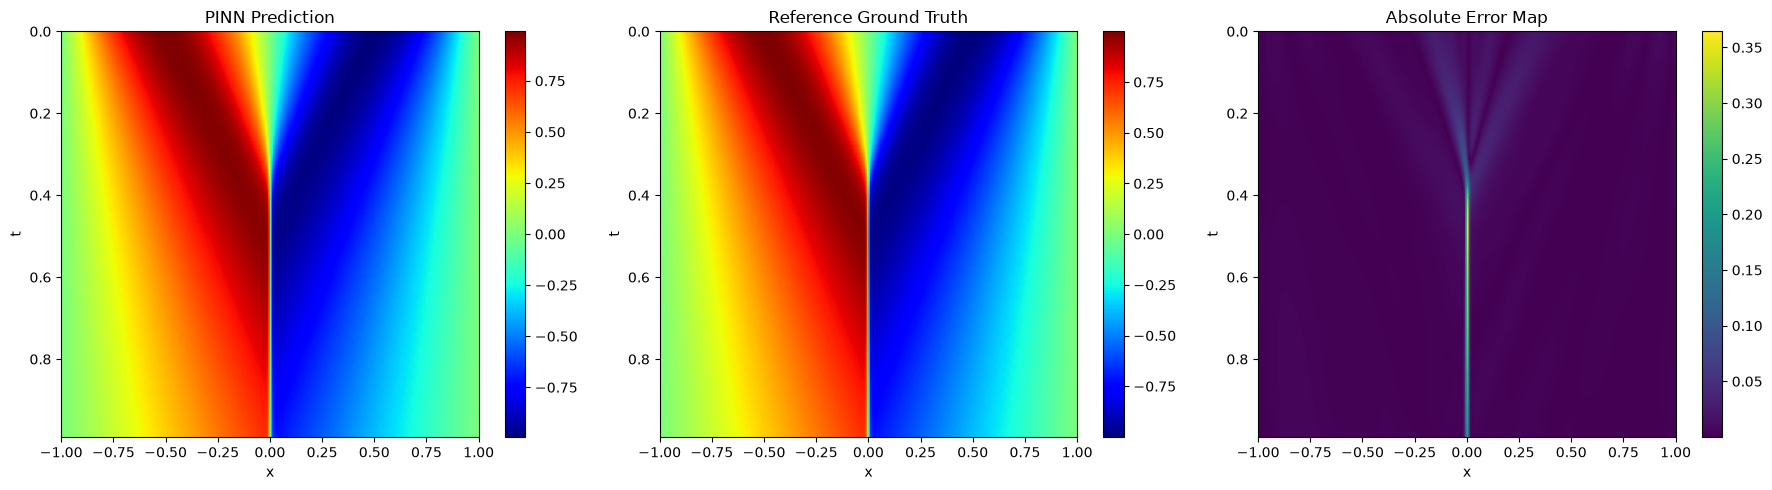

In [16]:
from sklearn.metrics import r2_score

model.eval()

# Generate assessment grid matching reference dimensions
X, T = np.meshgrid(x_ref, t_ref)
x_flat = torch.tensor(X.flatten(), dtype=torch.float32).reshape(-1, 1)
t_flat = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1, 1)

with torch.no_grad():
    u_pred = model(x_flat, t_flat).numpy().reshape(len(t_ref), len(x_ref))

# Metrics Calculation
error = np.abs(u_pred - u_ref)
r2 = r2_score(u_ref.flatten(), u_pred.flatten())
print(f"\nTraining Complete. R² Score: {r2*100:.2f}%")

# 2D Domain Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(u_pred, extent=[x_min, x_max, t_max, t_min], aspect='auto', cmap='jet')
axes[0].set_title('PINN Prediction')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_ref, extent=[x_min, x_max, t_max, t_min], aspect='auto', cmap='jet')
axes[1].set_title('Reference Ground Truth')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(error, extent=[x_min, x_max, t_max, t_min], aspect='auto', cmap='viridis')
axes[2].set_title('Absolute Error Map')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()


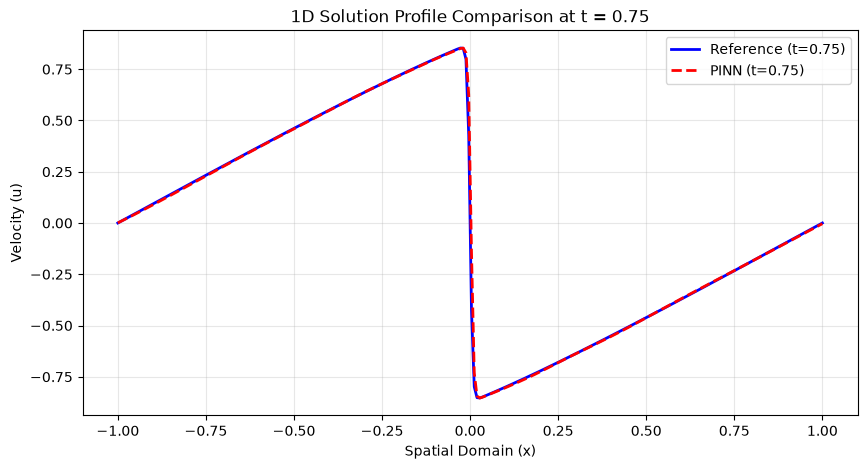

In [22]:
t_chosen = 0.75
# Dynamically locate the closest index matching our chosen timestamp
t_index = np.argmin(np.abs(t_ref - t_chosen))
actual_t = t_ref[t_index].item()

u_sol_slice = u_ref[t_index, :]

x_tensor = torch.tensor(x_ref, dtype=torch.float32).reshape(-1, 1)
t_tensor = torch.full((len(x_ref), 1), actual_t)
with torch.no_grad():
    u_pred_slice = model(x_tensor, t_tensor).flatten().numpy()

plt.figure(figsize=(10, 5))
plt.plot(x_ref, u_sol_slice, 'b-', linewidth=2, label=f'Reference (t={actual_t:.2f})')
plt.plot(x_ref, u_pred_slice, 'r--', linewidth=2, label=f'PINN (t={actual_t:.2f})')
plt.title(f'1D Solution Profile Comparison at t = {actual_t:.2f}')
plt.xlabel('Spatial Domain (x)')
plt.ylabel('Velocity (u)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [19]:
torch.save(model.state_dict(), 'PINN_Viscous_burgers_model.pth')